# Análise do Mercado de Games da Google Play Store

### Definição do Problema

**A indústria de jogos mobile é uma das maiores do mercado de aplicativos, movimentando bilhões de downloads e receitas globalmente.**

O objetivo deste projeto é analisar os principais jogos disponíveis na Google Play Store, identificando:

    Quais categorias de jogos possuem mais downloads
    Como as avaliações dos usuários impactam o sucesso dos jogos
    O crescimento dos jogos ao longo do tempo
    Diferenças entre jogos pagos e gratuitos

Com essa análise buscamos gerar insights que podem ajudar desenvolvedores e empresas a entender o comportamento do mercado mobile.

## Instalando e Carregando os Pacotes

In [1]:
# Imports

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
%matplotlib inline
sns.set()

In [2]:
dados = pd.read_csv("dados/dataset4.csv")

In [3]:
dados.shape

(1730, 15)

In [4]:
dados.head()

,rank,title,total ratings,installs,average rating,growth (30 days),growth (60 days),price,category,5 star ratings,4 star ratings,3 star ratings,2 star ratings,1 star ratings,paid
0,1,Garena Free Fire - The Cobra,80678661,500.0 M,4.33,2.9,7.9,0.0,GAME ACTION,61935712,4478738,2795172,1814999,9654037,False
1,2,PUBG MOBILE: Graffiti Prank,35971961,100.0 M,4.24,2.0,3.1,0.0,GAME ACTION,26670566,2109631,1352610,893674,4945478,False
2,3,Mobile Legends: Bang Bang,25836869,100.0 M,4.08,1.6,3.3,0.0,GAME ACTION,17850942,1796761,1066095,725429,4397640,False
3,4,Brawl Stars,17181659,100.0 M,4.27,4.1,6.6,0.0,GAME ACTION,12493668,1474319,741410,383478,2088781,False
4,5,Sniper 3D: Fun Free Online FPS Shooting Game,14237554,100.0 M,4.33,0.8,1.8,0.0,GAME ACTION,9657878,2124544,1034025,375159,1045945,False


In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1730 entries, 0 to 1729
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rank              1730 non-null   int64  
 1   title             1730 non-null   object 
 2   total ratings     1730 non-null   int64  
 3   installs          1730 non-null   object 
 4   average rating    1730 non-null   float64
 5   growth (30 days)  1730 non-null   float64
 6   growth (60 days)  1730 non-null   float64
 7   price             1730 non-null   float64
 8   category          1730 non-null   object 
 9   5 star ratings    1730 non-null   int64  
 10  4 star ratings    1730 non-null   int64  
 11  3 star ratings    1730 non-null   int64  
 12  2 star ratings    1730 non-null   int64  
 13  1 star ratings    1730 non-null   int64  
 14  paid              1730 non-null   bool   
dtypes: bool(1), float64(4), int64(7), object(3)
memory usage: 191.0+ KB


**Criando uma cópia para análise::**

In [6]:
data1 = dados.copy()
data1.installs.unique()

array(['500.0 M', '100.0 M', '50.0 M', '10.0 M', '5.0 M', '1.0 M',
       '1000.0 M', '500.0 k', '100.0 k'], dtype=object)

**Convertendo a variável installs para formato numérico**

In [7]:
install_range = {'500.0 M': 500000000, 
                 '100.0 M': 100000000, 
                 '50.0 M': 50000000, 
                 '10.0 M': 10000000, 
                 '5.0 M': 5000000, 
                 '1.0 M': 1000000,
                 '1000.0 M': 1000000000 , 
                 '500.0 k': 500000, 
                 '100.0 k': 1000000}

In [8]:
data1['Installs_num'] = data1['installs'].map(install_range)

In [9]:
data1

,rank,title,total ratings,installs,average rating,growth (30 days),growth (60 days),price,category,5 star ratings,4 star ratings,3 star ratings,2 star ratings,1 star ratings,paid,Installs_num
0,1,Garena Free Fire - The Cobra,80678661,500.0 M,4.33,2.9,7.9,0.0,GAME ACTION,61935712,4478738,2795172,1814999,9654037,False,500000000
1,2,PUBG MOBILE: Graffiti Prank,35971961,100.0 M,4.24,2.0,3.1,0.0,GAME ACTION,26670566,2109631,1352610,893674,4945478,False,100000000
2,3,Mobile Legends: Bang Bang,25836869,100.0 M,4.08,1.6,3.3,0.0,GAME ACTION,17850942,1796761,1066095,725429,4397640,False,100000000
3,4,Brawl Stars,17181659,100.0 M,4.27,4.1,6.6,0.0,GAME ACTION,12493668,1474319,741410,383478,2088781,False,100000000
4,5,Sniper 3D: Fun Free Online FPS Shooting Game,14237554,100.0 M,4.33,0.8,1.8,0.0,GAME ACTION,9657878,2124544,1034025,375159,1045945,False,100000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1725,96,Piknik Słowo - Word Snack,122845,1.0 M,4.67,0.1,0.3,0.0,GAME WORD,96954,17233,5098,1249,2309,False,1000000
1726,97,Wordox – Free multiplayer word game,120476,1.0 M,4.21,0.0,0.1,0.0,GAME WORD,74010,21546,10648,4710,9560,False,1000000
1727,98,4 Fotos 1 Palavra,114852,5.0 M,4.52,0.3,0.6,0.0,GAME WORD,84688,16783,6619,1867,4892,False,5000000
1728,99,زوايا - لعبة ستحرك زوايا عقلك,110293,1.0 M,4.76,0.8,1.9,0.0,GAME WORD,99168,3528,3258,1059,3278,False,1000000


#### Análise de Instalações por Categoria

Agrupando os downloads por categoria:

In [10]:
total_install_cat = data1.groupby('category')['Installs_num'].sum().sort_values(ascending = False)

In [11]:
total_install_cat

category
GAME ARCADE          6931000000
GAME CASUAL          6847000000
GAME ACTION          6650000000
GAME RACING          4640000000
GAME PUZZLE          3631000000
GAME SPORTS          3491000000
GAME SIMULATION      2871000000
GAME STRATEGY        2392000000
GAME BOARD           2038000000
GAME ADVENTURE       1888000000
GAME EDUCATIONAL     1595500000
GAME ROLE PLAYING    1449000000
GAME CARD            1401000000
GAME WORD            1385000000
GAME MUSIC           1286500000
GAME CASINO           788500000
GAME TRIVIA           705000000
Name: Installs_num, dtype: int64

#### Visualização das Categorias Mais Populares

**Gráfico de barras na horizontal com o total de games e total de instalações por categoria**

As categorias com maior número de downloads são:

Arcade | Casual | Action

Isso indica que jogos simples e rápidos tendem a atingir maior público no mercado mobile.

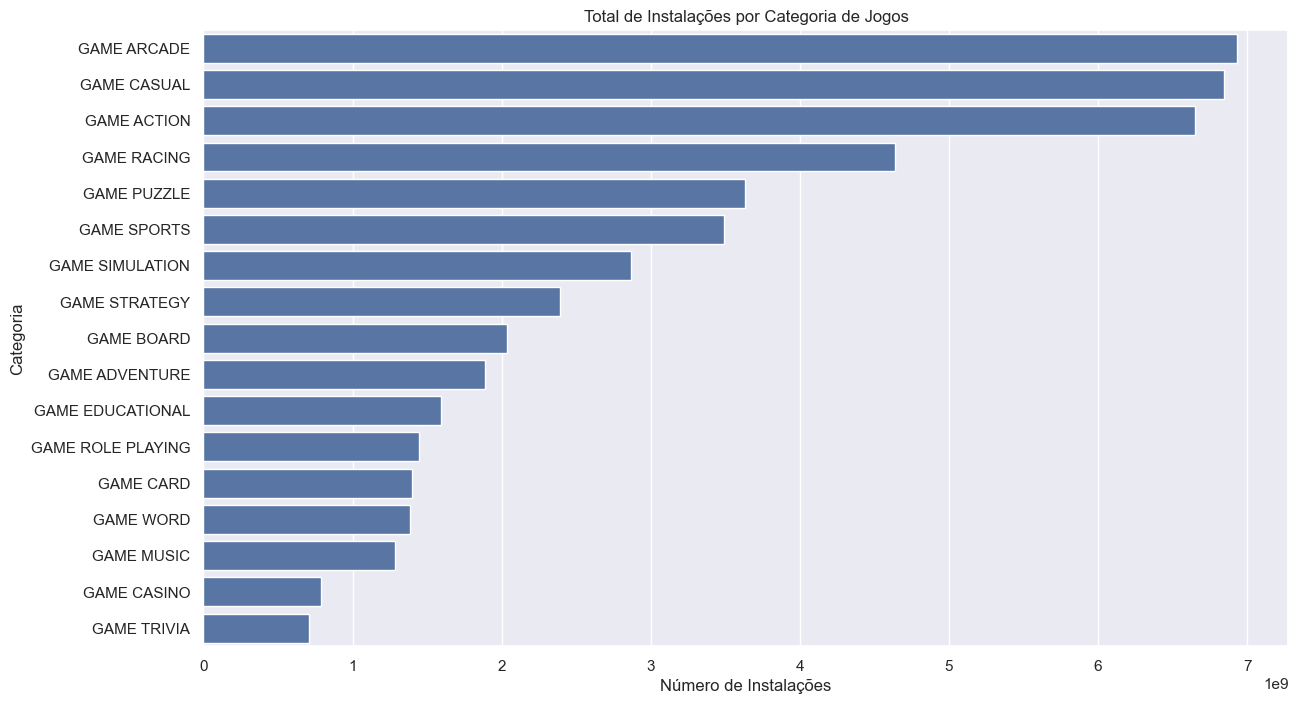

In [12]:
plt.figure(figsize=(14,8))

sns.barplot(
    y=total_install_cat.index,
    x=total_install_cat.values
)

plt.title("Total de Instalações por Categoria de Jogos")
plt.xlabel("Número de Instalações")
plt.ylabel("Categoria")

plt.show()

**Pie Chart com o percentual de games por categoria**

O mercado apresenta forte concentração em algumas categorias, principalmente:

Action | Casual | Arcade

Esses gêneros dominam o volume total de jogos disponíveis.

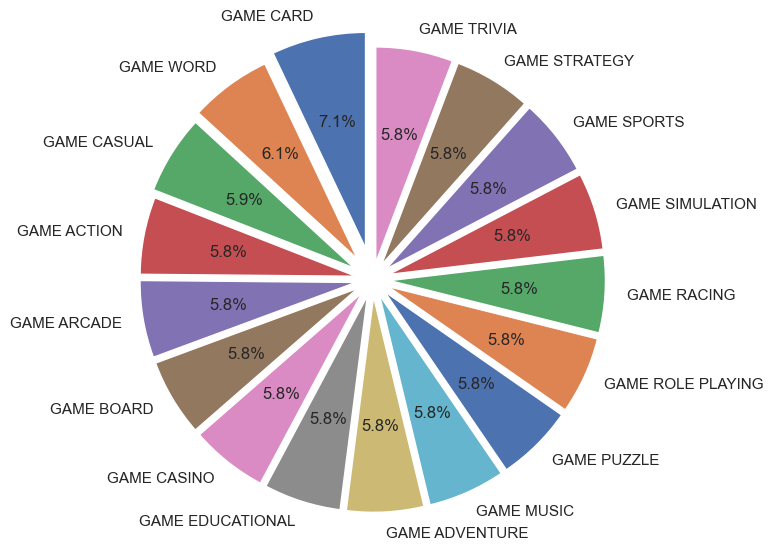

In [13]:
# Dataviz 28
plt.figure(figsize = (14,7))
cat_labels = data1['category'].value_counts().index
plt.pie(data1['category'].value_counts().values, 
        labels = cat_labels, 
        autopct = '%1.1f%%', 
        startangle = 90,
        explode = [0.15, 0.12, 0.1, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08])

plt.show()

#### Relação entre Avaliações e Popularidade

Jogos com avaliação superior a 4.0 estrelas tendem a apresentar maior volume de downloads, indicando que qualidade percebida influencia diretamente a popularidade.

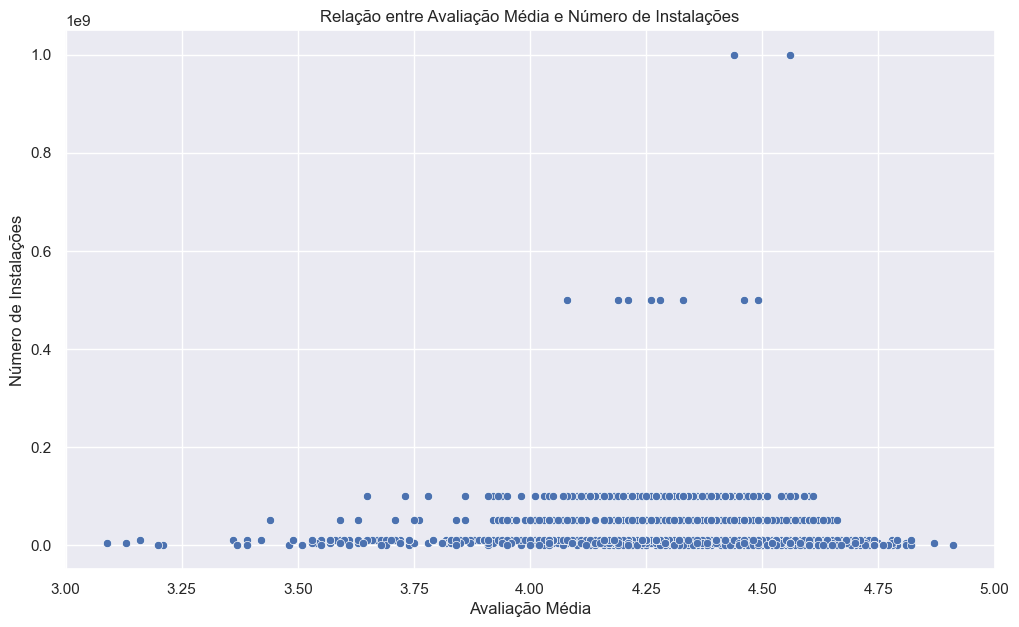

In [14]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    x="average rating",
    y="Installs_num",
    data=data1
)

plt.title("Relação entre Avaliação Média e Número de Instalações")

plt.xlabel("Avaliação Média")
plt.ylabel("Número de Instalações")

plt.show()

#### Jogos Pagos vs Gratuitos

Resultado:

* 99% dos jogos são gratuitos
* apenas 0.4% são pagos

**Sunburst dos 20 primeiros games com a categoria, média de avaliação e se é pago ou gratuito**

In [15]:
data1.paid.value_counts()

paid
False    1723
True        7
Name: count, dtype: int64

In [16]:
data1.head(20)

,rank,title,total ratings,installs,average rating,growth (30 days),growth (60 days),price,category,5 star ratings,4 star ratings,3 star ratings,2 star ratings,1 star ratings,paid,Installs_num
0,1,Garena Free Fire - The Cobra,80678661,500.0 M,4.33,2.9,7.9,0.0,GAME ACTION,61935712,4478738,2795172,1814999,9654037,False,500000000
1,2,PUBG MOBILE: Graffiti Prank,35971961,100.0 M,4.24,2.0,3.1,0.0,GAME ACTION,26670566,2109631,1352610,893674,4945478,False,100000000
2,3,Mobile Legends: Bang Bang,25836869,100.0 M,4.08,1.6,3.3,0.0,GAME ACTION,17850942,1796761,1066095,725429,4397640,False,100000000
3,4,Brawl Stars,17181659,100.0 M,4.27,4.1,6.6,0.0,GAME ACTION,12493668,1474319,741410,383478,2088781,False,100000000
4,5,Sniper 3D: Fun Free Online FPS Shooting Game,14237554,100.0 M,4.33,0.8,1.8,0.0,GAME ACTION,9657878,2124544,1034025,375159,1045945,False,100000000
5,6,Shadow Fight 2,14048931,100.0 M,4.57,0.6,1.5,0.0,GAME ACTION,11532143,961926,448184,217044,889631,False,100000000
6,7,Call of Duty®: Mobile - Day of Reckoning,13020115,100.0 M,4.47,2.8,5.1,0.0,GAME ACTION,10079925,1210326,488294,261610,979958,False,100000000
7,8,Among Us,11298789,100.0 M,3.65,6.3,12.3,0.0,GAME ACTION,6173970,1026476,770574,614021,2713745,False,100000000
8,9,Temple Run 2,9554877,500.0 M,4.21,0.3,0.6,0.0,GAME ACTION,6521348,996144,615544,343978,1077860,False,500000000
9,10,PUBG MOBILE LITE,7392911,100.0 M,4.16,1.3,2.9,0.0,GAME ACTION,5231571,494013,343880,232468,1090976,False,100000000


**O modelo predominante no mercado mobile é Free-to-Play/Gratuito para jogar, com monetização através de:**

microtransações | anúncios | compras dentro do aplicativo

#### Análise dos Jogos Mais Populares:

Essa visualização mostra:

hierarquia entre jogo → categoria → modelo de monetização

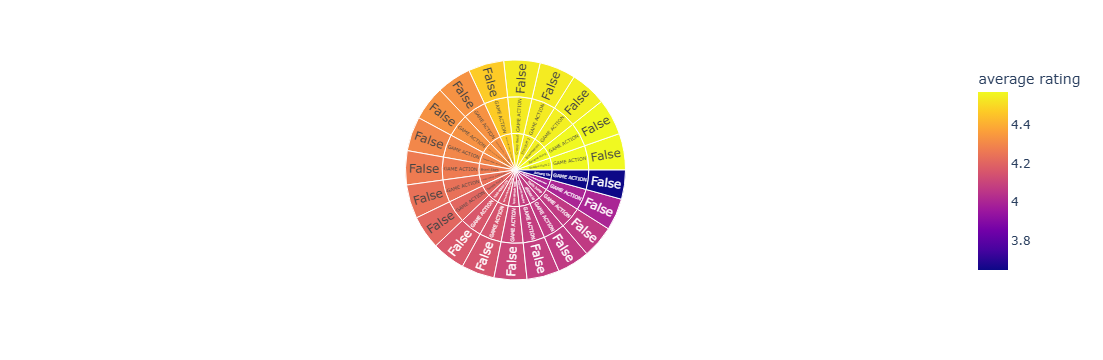

In [17]:
# Dataviz 

px.sunburst(data1.head(20), 
            path = ['title', 'category', 'paid'], 
            values = 'average rating', 
            color = 'average rating')

#### A análise revela padrões importantes do mercado mobile:

🎮 **Domínio de categorias específicas**

    Arcade, Casual e Action concentram a maior parte dos downloads.

⭐ **Avaliações impactam downloads**

    Jogos com nota superior a 4 estrelas tendem a alcançar maior popularidade.

💰 **Modelo de monetização dominante**

    O modelo Free-to-Play domina completamente o mercado, sendo utilizado pela grande maioria dos jogos.

📈 **Crescimento acelerado de alguns títulos**

    Jogos com crescimento elevado em 30 e 60 dias indicam tendências virais no mercado mobile.

#### Conclusão

A partir da análise foi possível identificar:

        categorias mais populares
        impacto das avaliações no sucesso
        modelos de monetização predominantes

Essas informações podem auxiliar empresas de jogos, desenvolvedores e analistas de mercado na tomada de decisões estratégicas.

# Fim